# BERT Preprocessing + Classifier Model Hybrid for Phishing Detection

For more information regarding the model and other important information, check the README file.

**AVN Phishing Email Classification Dataset**\
From AVN Bluefox (Amritha V Nair) - 2025. Under CC BY 4.0 License\
https://www.kaggle.com/datasets/avnbluefox/avn-phishing-email-classification-dataset?select=AVN_Corpus.csv

## Exploratory Data Analysis

In [1]:
from email.utils import parseaddr

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2026-08-11 12:23:34.554119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-11 12:23:34.616522: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-11 12:23:36.084839: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/prism/dev/repos/phishing-detection-with-bert-preprocessing/.venv/lib/python3.12/site-

In [2]:
df = pd.read_csv('data/AVN_Corpus.csv')
df

,subject,receiver,sender,label,body,urls,date
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,"Tue, 05 Aug 2008 16:31:02 -0700"
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,"Tue, 05 Aug 2008 18:31:03 -0500"
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,"Tue, 05 Aug 2008 20:28:00 -1200"
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,"Tue, 05 Aug 2008 17:31:20 -0600"
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,"Tue, 05 Aug 2008 19:31:21 -0400"
...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,NaN,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,NaN
59432,TREAT AS URGENT.,NaN,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,"Mon, 17 Sep 2007 22:28:11 +0000"
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,NaN,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,"Tue, 18 Sep 2007 10:54:53 +0000"
59434,My Beloved In Christ.,NaN,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,"Wed, 19 Sep 2007 00:52:16 +0100"


We first check to see the distribution of null values to see how we should perform data cleaning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59436 entries, 0 to 59435
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   48209 non-null  str    
 1   receiver  46296 non-null  str    
 2   sender    47961 non-null  str    
 3   label     59436 non-null  float64
 4   body      59436 non-null  str    
 5   urls      59436 non-null  int64  
 6   date      47810 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 3.2 MB


We first perform checks on the `label` variable to identify any potential class imbalance within the dataset.

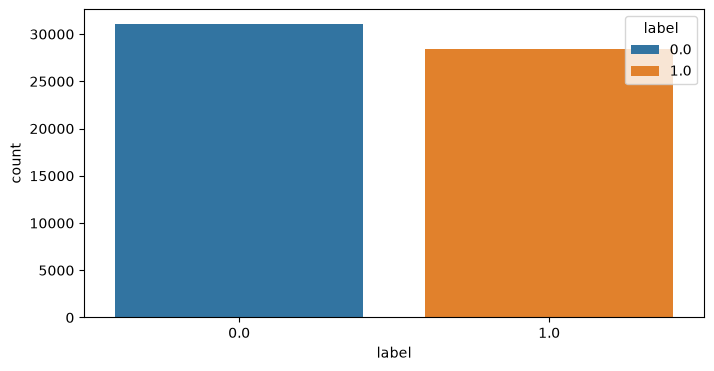

label
0.0    31053
1.0    28383
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', hue='label')
plt.show()

df['label'].value_counts()

From the `label` data above, the class distribution is roughly **even**, with a distribution of:
- 31,053 (52.2%) of emails being normal
- 28,383 (47.8%) of emails being malicious

The null values with `subject`, `sender`, `receiver` and `date` fields make up ~20% of the total number of fields within the dataset.

Hence, we fill the null values for `subject`, `sender` and `receiver` with **"Unknown"** fields as these null values can have potentially reveal special relationships within the data.

For the `date` field, an indicator `is_date_valid` to check whether it has a defined (and valid) date and then parse the value within `date` (see below).

In [5]:
df["subject"] = df["subject"].fillna("No Subject")
df["sender"] = df["sender"].fillna("Unknown Sender")
df["receiver"] = df["receiver"].fillna("Unknown Receiver")

df["is_date_invalid"] = df["date"].isna().astype(np.float32)  # 1 if invalid, 0 if valid

df.sample(5)

,subject,receiver,sender,label,body,urls,date,is_date_invalid
45191,No Subject,Unknown Receiver,Unknown Sender,0.0,Ok i am on the way to railway,0,NaN,1.0
37122,CNN Alerts: My Custom Alert,email1710@gvc.ceas-challenge.cc,CNN Alerts <merkkejk1993@msxi.com>,1.0,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,0,"Fri, 08 Aug 2008 07:33:56 -0400",0.0
8411,Re: [opensuse] Parted question,rqby.rvqvtpq@gmail.com,Hans defaber <rqby.rvqvtpq@gmail.com>,0.0,"Hans defaber schreef:\n> Hello everybody,\n> \...",0,"Wed, 06 Aug 2008 06:24:19 +0100",0.0
25576,[Python-Dev] strange import encodings error in...,"""zvllln-eum@python.org"" <zvllln-eum@python.org>","""Gregory P. Smith"" <amuh@krypto.org>",0.0,has anyone ever seen this error? this is a pr...,0,"Thu, 07 Aug 2008 06:49:09 -0700",0.0
2014,[UAI] NIPS final call for DEMOS,faq@cs.orst.edu,Tobi Delbruck <qnbt@ini.phys.ethz.ch>,0.0,Would you like to interactively demonstra...,1,"Tue, 05 Aug 2008 17:10:08 -0700",0.0


The `date` column **is adjusted for UTC**, and then parsed into 4 unique fields which are:
- `hour`
- `day_of_week`: day of the week (Mon (0) - Sun (6))
- `month`
- `year`

The original `date` column will be dropped.

In [6]:
df['date'] = pd.to_datetime(df['date'], errors="coerce", utc=True)

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df = df.drop('date', axis=1)

df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,month,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,8.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,8.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,8.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,8.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,8.0,2008.0
...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,9.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,9.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,9.0,2007.0


With the extracted subfields, we perform EDA to explore patterns with how these features interact with the target variable.

We first analyze the distribution of emails based on the time of day (`hour`), to answer whether:
- Are phishing emails more common within certain times of the day, such as working hours?
- Do most legitimate emails occur within the same time range as most phishing emails?

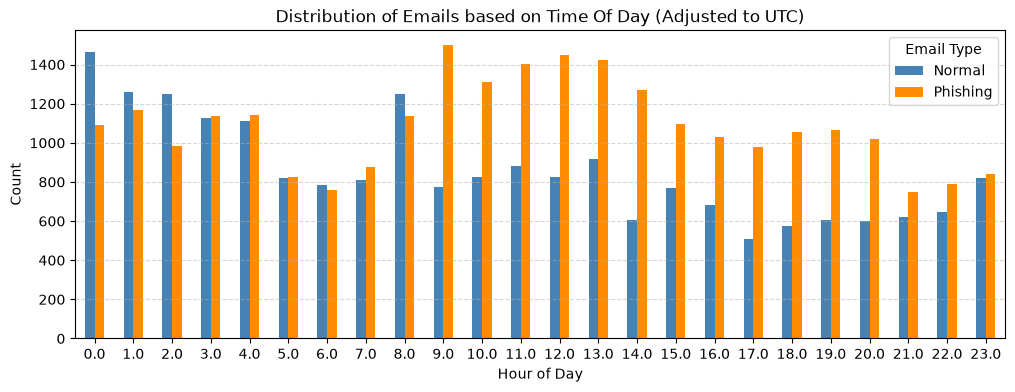

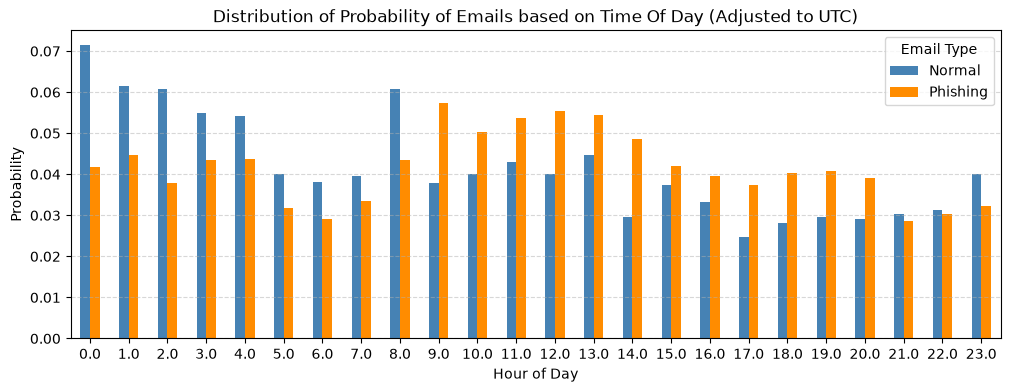

In [7]:
# pure count
counts = pd.crosstab(df['hour'], df['label'])
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['hour'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Probability of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Based on the distribution of data, we find that:
- Most phishing emails are present throughout **09:00 to 20:00 UTC**, with most legitimate ones being distributed mostly between **23:00 to 04:00** and **08:00 UTC**
- There is a **clear difference** between the distribution of normal and phishing emails

Hence, we keep the `hour` feature as we believe that this feature contains useful predictive power.

After parsing `hour`, we then analyze the day of the week (`day_of_week`) to answer:
- Are phishing emails more common within weekdays as supposed to weekends?
- What is the overall distribution of emails within the week?

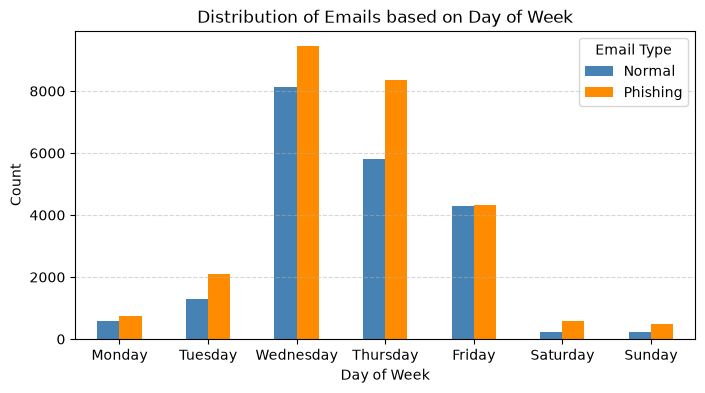

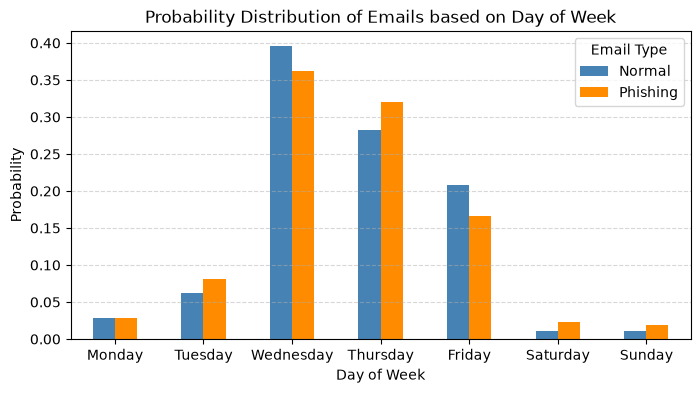

In [8]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# pure count
counts = pd.crosstab(df['day_of_week'], df['label'])
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['day_of_week'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Probability Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Majority** of all emails fall within **Wednesday to Friday**, with the **weekends tending to have significant lower emails**
- Normal emails and phishing emails follow the **same trend** throughout the week

Therefore, we keep the `day_of_week` feature as we believe that feature is useful in predicting the trends of emails throughout the week.

After parsing `month`, we then analyze the month of the year (`month`) to answer:
- Are there any trends in phishing emails based on the months of the year?
- What is the overall distribution of emails within the year, do summer / winter holiday periods reduce the number?

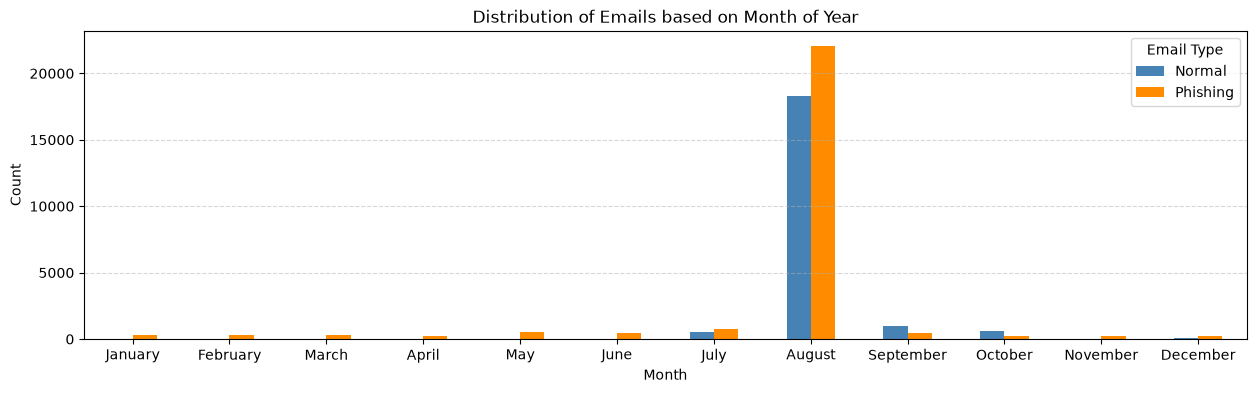

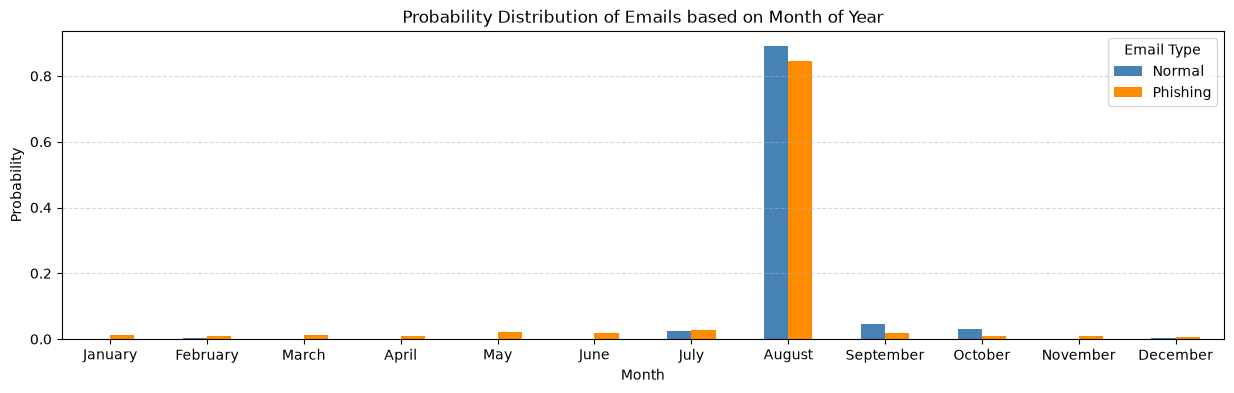

In [9]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# pure count
counts = pd.crosstab(df['month'], df['label'])
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['month'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Probability Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Practically all emails are sent from August**, other months have a *negligible* percentage of emails
- Both normal and phishing emails follow this trend

Thus, we decide to drop `month`, since we believe that this distribution is because of how the data within the dataset was obtained.

In [10]:
df = df.drop('month', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,2008.0
...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,2007.0


The `year` column, just like `month`, contains a heavily imbalanced set, with **2008 making up more than 65% of emails**.

Hence, we also drop `year` since it doesn't contain any useful predictive value.

In [11]:
df['year'].value_counts()

year
2008.0    38947
2002.0     4548
2006.0     1006
2005.0      553
2007.0      466
2004.0      424
2003.0      396
2001.0      109
102.0        59
2000.0       35
2009.0       15
1980.0       12
1998.0        7
1999.0        6
2100.0        4
2020.0        4
1986.0        2
1990.0        2
2086.0        1
2012.0        1
2080.0        1
2031.0        1
1981.0        1
2010.0        1
2028.0        1
1997.0        1
2082.0        1
2015.0        1
Name: count, dtype: int64

In [12]:
df = df.drop('year', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0
...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0


For `sender`, it would likely better to extract the features given that the domain of the email and other information is more useful.
The `receiver` would not be useful as it is random dependent on whom the attacker targets.

We use the `parseaddr()` function provided by Python's `email` stdlib import, which handles most of the raw email parsing.
After parsing, we split the contents of the email into different components, like name, username, domain, TLD, before feature engineering.

From these components, we then obtain the following features:
- **Boolean variables**: 1 for yes, 0 for no
    - `is_sender_name_missing`
    - `is_sender_email_missing`
    - `sender_email_has_digits`
    - `sender_email_has_hyphens`
- **Countable variables**
    - `sender_username_length`
    - `sender_domain_length`

In [13]:
def parse_sender_receiver(raw):
    name, email = parseaddr(raw)
    name = name.strip().replace('\\"', '"').strip('"').strip()
    email = email.lower().strip()
    return name, email


def extract_email_components(email):
    if '@' not in email:
        return "", ""
    username, domain = email.split('@', 1)
    return username, domain


df[["sender_displayname", "sender_email"]] = df['sender'].apply(parse_sender_receiver).apply(pd.Series)

df[["sender_username", "sender_domain"]] = df["sender_email"].apply(extract_email_components).apply(pd.Series)

df["is_sender_displayname_missing"] = (df["sender_displayname"] == "").astype(int)
df["is_sender_email_missing"] = (df["sender_email"].str.contains("@", na=False) == False).astype(int)

df["sender_email_digit_count"] = df["sender_email"].str.count(r"\d")
df["sender_email_has_hyphens"] = df["sender_email"].str.contains("-").astype(int)

df['sender_username_length'] = df['sender_username'].str.len()

df['sender_domain_length'] = df['sender_domain'].str.len()

# drop the sender and receiver column, as well as the other temporary features
df = df.drop(['sender', 'sender_displayname', 'sender_email', 'sender_username', 'sender_domain', 'receiver'], axis=1)
df

,subject,label,body,urls,is_date_invalid,hour,day_of_week,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,0,0,0,0,5,9
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,0,0,4,0,12,9
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,0,0,0,1,19,19
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,0,0,0,0,7,9
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,0,0,1,0,12,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,1,0,4,0,14,14
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,0,0,3,0,13,10
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,0,0,2,0,18,10
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,0,0,2,0,14,11


We first perform EDA on the boolean variables, by analyzing what is the proportion of phishing emails and normal emails correlate with these features.

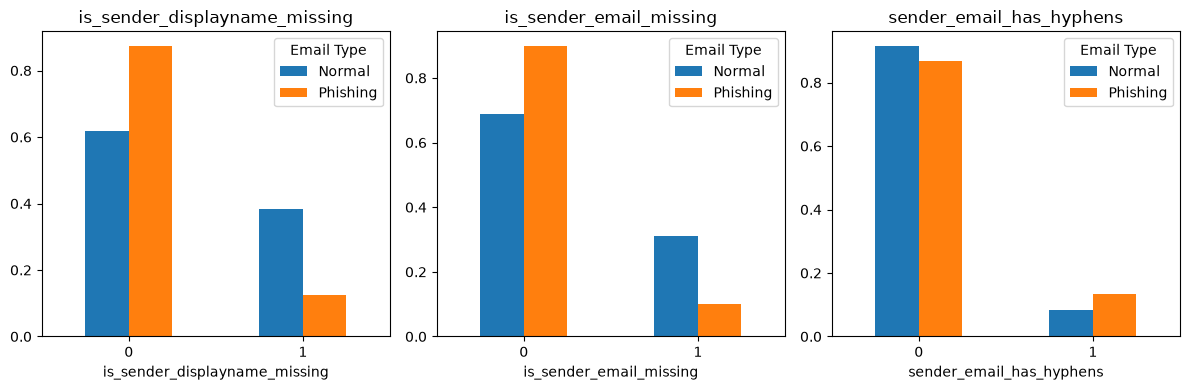

In [14]:
bool_features = [
    "is_sender_displayname_missing",
    "is_sender_email_missing",
    "sender_email_has_hyphens",
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, feature in zip(axes.flatten(), bool_features):
    pd.crosstab(
        df[feature],
        df["label"],
        normalize='columns'
    ).plot(kind='bar', ax=ax)
    ax.legend(title="Email Type", labels=["Normal", "Phishing"])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(feature)

plt.tight_layout()

Based on the results, we find that:
- Emails where the **sender has hyphens** are slightly more likely to be a phishing email than a normal email
- Normal emails are **more likely to have the sender email / display name missing** compared to a phishing email, contrary to assumptions

We then analyze the countable features, to look at the trend of how the distributions differ between legitimate and phishing emails

sender_username_length                      sender_email_digit_count  \
                      median       mean       std                   median   
label                                                                        
0.0                      5.0   5.821531  5.529793                      0.0   
1.0                     11.0  10.598386  6.063010                      0.0   

                          sender_domain_length                       
           mean       std               median       mean       std  
label                                                                
0.0    0.155991  0.981839                  9.0   8.510869  6.835133  
1.0    0.868513  1.853595                 12.0  11.745939  5.692323

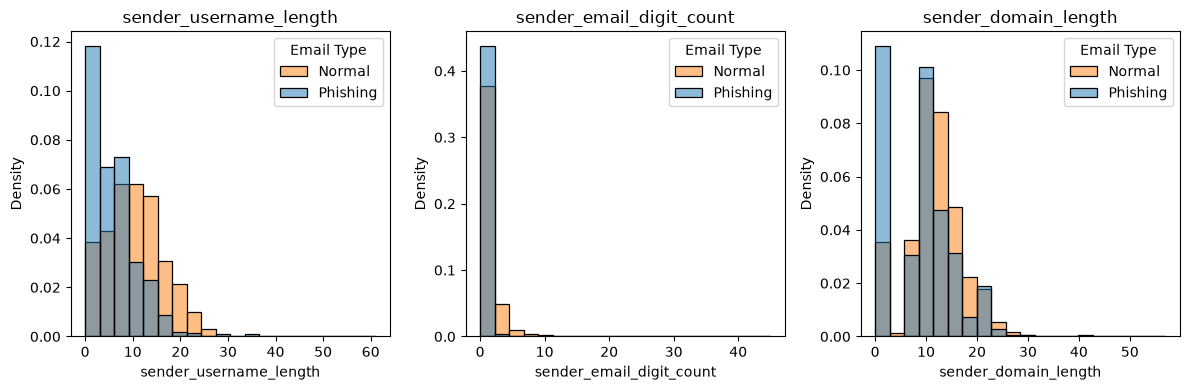

In [15]:
count_features = [
    "sender_username_length",
    "sender_email_digit_count",
    "sender_domain_length",
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, feature in zip(axes.flatten(), count_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="label",
        bins=20,
        stat="density",
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.legend(title="Email Type", labels=["Normal", "Phishing"])
    ax.set_title(feature)

plt.tight_layout()

df.groupby("label")[count_features].agg(
    ['median', 'mean', 'std']
)

From the results, we find that:
- Normal sender email addresses within `sender_username_length` tend towards **shorter usernames**, while phishing emails tend to come from senders with longer username.
This is shown in the normal email median length being 5, as compared with 11 for the median phishing email length.
- Sender email addresses with **lower or no digits** (`sender_email_digit_count`) tend to be normal emails as compared with phishing emails. This is shown through the mean count of digits in normal
emails is 0.16, as 0.87 for phishing emails.
- Sender email addresses with **longer domain lengths** (`sender_domain_length`) are more likely to be phishing emails then normal emails
which is expected since attackers don't have control over the recipient's email address and domain

After performing feature extraction, we perform correlation analysis on the numerical features to find relations between the different features, alongside the relationship in
how each feature affects the target variable `label`.

We plot a heatmap showing the relationship of the entire dataset, alongside a correlation plot of each numerical feature against the target variable `label`

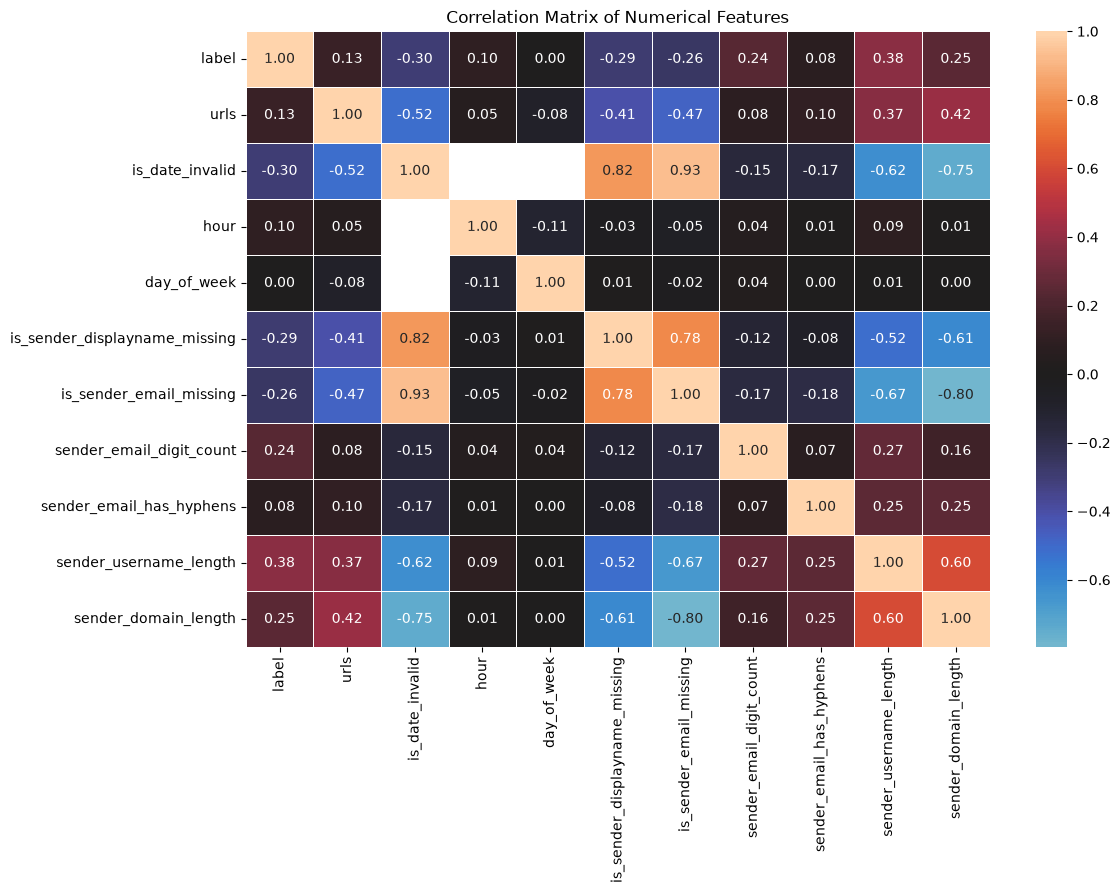

In [16]:
numeric_features = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

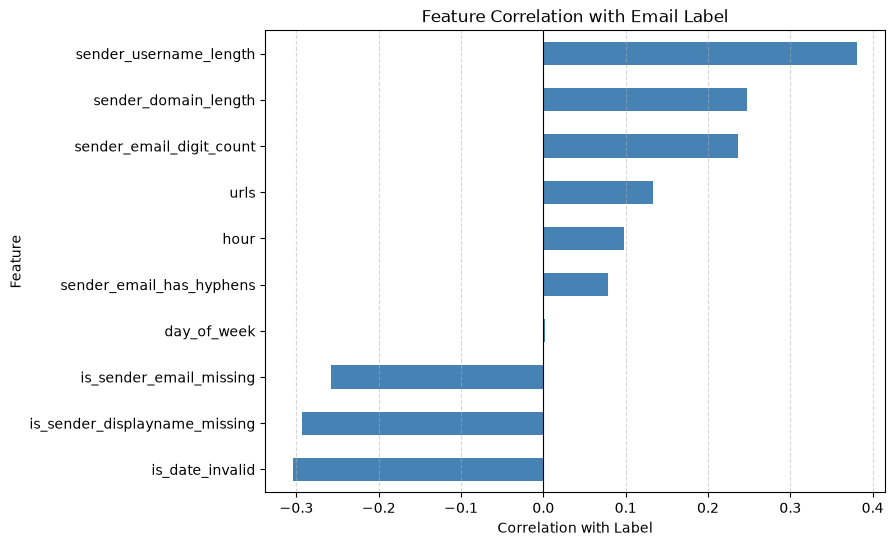

is_date_invalid                 -0.303652
is_sender_displayname_missing   -0.292932
is_sender_email_missing         -0.257385
day_of_week                      0.002458
sender_email_has_hyphens         0.078989
hour                             0.098468
urls                             0.133169
sender_email_digit_count         0.236169
sender_domain_length             0.247891
sender_username_length           0.380983
Name: label, dtype: float64

In [17]:
label_corr = (
    df.select_dtypes(include=[np.number])
    .corr()['label']
    .drop('label')
    .sort_values()
)

plt.figure(figsize=(8, 6))
label_corr.plot(kind='barh', color='steelblue')

plt.title("Feature Correlation with Email Label")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")

plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

label_corr

From the heatmap, we find that the strongest positive correlation with the target was observed for `sender_username_length` with a correlation factor of +0.38,
suggesting that phishing emails tend to contain longer sender usernames. `sender_domain_length` (0.25) and `sender_email_digit_count` (0.24) also
show notable positive relationships with the phishing label.

Conversely, `is_date_invalid` (-0.30), `is_sender_displayname_missing` (-0.29) and `is_sender_email_missing` (-0.26) showed negative correlations with the target.
This suggests that emails with missing sender information or invalid dates are more commonly associated with normal email labels in this dataset.

The `urls` (0.13), `hour` (0.10), `sender_email_has_hyphens` (0.08) and `day_of_week` (~0.00) features show low linear correlation with the target.
However, these low correlations do not necessarily indicate that these features have no predictive value, as correlation only captures linear relationships.

## Data Cleaning & Preprocessing

After completing EDA, we now prepare the dataset for the model.

The `hour` and `day_of_week` are **periodic features** (i.e. they happen in cycles and repeat),
hence encoding this features with a raw number may result in models seeing a big jump between values that are actually adjacent,
such as between **11:00 PM (23)** and **12:00AM (0)** for `hour`.

Therefore, in order to ensure that the model capture the cyclic nature of these features, we use **cyclic encoding** (sin / cos) to encode these fields.

**Both the sine and cosine** is used to create unique values for each value of `hour` and `day_of_week`,
since just using one function results in duplicates sharing the same value.

The original `hour` and `day_of_week` fields are dropped.

,subject,label,body,urls,is_date_invalid,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,0,0,0,0,5,9,-0.258819,0.965926,0.781831,0.623490
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,0,0,4,0,12,9,-0.258819,0.965926,0.781831,0.623490
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,0,0,0,1,19,19,0.866025,-0.500000,0.974928,-0.222521
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,0,0,0,0,7,9,-0.258819,0.965926,0.781831,0.623490
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,0,0,1,0,12,19,-0.258819,0.965926,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,1,0,4,0,14,14,0.000000,0.000000,0.000000,0.000000
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,0,0,3,0,13,10,-0.500000,0.866025,0.000000,1.000000
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,0,0,2,0,18,10,0.500000,-0.866025,0.781831,0.623490
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,0,0,2,0,14,11,-0.258819,0.965926,0.781831,0.623490


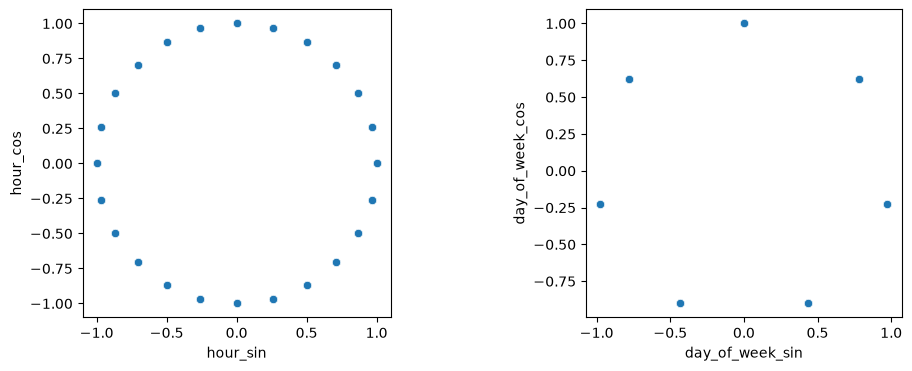

In [18]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

df = df.drop(['hour', 'day_of_week'], axis=1)

# we encode the features with both sin and cos to allow the model to capture the relationship below
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(df, x='hour_sin', y='hour_cos', ax=ax[0]).set_aspect('equal')
sns.scatterplot(df, x='day_of_week_sin', y='day_of_week_cos', ax=ax[1]).set_aspect('equal')
plt.plot()

# handle any null values
df[['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']] = df[['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']].fillna(0)

df

To keep consistent with the labels, we rename `urls` to `does_body_contain_urls`

In [19]:
df["does_body_contains_urls"] = df["urls"]
df = df.drop('urls', axis=1)
df

,subject,label,body,is_date_invalid,is_sender_displayname_missing,is_sender_email_missing,sender_email_digit_count,sender_email_has_hyphens,sender_username_length,sender_domain_length,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,does_body_contains_urls
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",0.0,0,0,0,0,5,9,-0.258819,0.965926,0.781831,0.623490,1
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,0.0,0,0,4,0,12,9,-0.258819,0.965926,0.781831,0.623490,1
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,0.0,0,0,0,1,19,19,0.866025,-0.500000,0.974928,-0.222521,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,0.0,0,0,0,0,7,9,-0.258819,0.965926,0.781831,0.623490,1
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,0.0,0,0,1,0,12,19,-0.258819,0.965926,0.781831,0.623490,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",1.0,1,0,4,0,14,14,0.000000,0.000000,0.000000,0.000000,0
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,0.0,0,0,3,0,13,10,-0.500000,0.866025,0.000000,1.000000,1
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,0.0,0,0,2,0,18,10,0.500000,-0.866025,0.781831,0.623490,1
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",0.0,0,0,2,0,14,11,-0.258819,0.965926,0.781831,0.623490,1


For pre-processing the `body` and `subject`, we use a BERT preprocessor and backbone (from KerasHub) to bring the two features together before passing it to the model.

Hence, since `body` and `subject` works with tokens and not numerical values, we seperate it from our numerical features after spliting.

In [20]:
X = df.drop(['label'], axis=1)
y = df['label']

X_train, X_remain, y_train, y_remain = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_validate, X_test, y_validate, y_test = train_test_split(X_remain, y_remain, test_size=0.5, random_state=42, stratify=y_remain)

X_train_text = X_train[["subject", "body"]]
X_test_text = X_test[["subject", "body"]]
X_validate_text = X_validate[["subject", "body"]]

X_train = X_train.drop(['subject', 'body'], axis=1)
X_test = X_test.drop(['subject', 'body'], axis=1)
X_validate = X_validate.drop(['subject', 'body'], axis=1)

Since the dataset features have different value ranges, we scale them using `StandardScaler`.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_validate_scaled = scaler.transform(X_validate)

X_train_scaled.shape

(47548, 12)

Now, we perform processing on `body` and `subject` to obtain embeddings from the tokens to be combined with the main dataset.

We first concatenate the `subject` and `body` together as a single string before passing it into BERT.

This is done so that the model is able to capture the relationship between the `subject` and `body` fields within the email.

In [22]:
X_train_text = (
        X_train_text["subject"] +
        " [SEP] " +
        X_train_text["body"]
)

X_validate_text = (
        X_validate_text["subject"] +
        " [SEP] " +
        X_validate_text["body"]
)

X_test_text = (
        X_test_text["subject"] +
        " [SEP] " +
        X_test_text["body"]
)

We define the BERT preprocessor that will parse the text into tokens that can be used for creating the embeddings, and pass each `X` into it.

Within each email, we use the default `sequence_length` of 512 tokens.

In [23]:
# gpu optimization
keras.mixed_precision.set_global_policy("mixed_float16")

preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=512,
)

I0000 00:00:1786422237.394064  299087 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [24]:
train_tokens = preprocessor(tf.constant(X_train_text.tolist(), dtype=tf.string))
validate_tokens = preprocessor(tf.constant(X_validate_text.tolist(), dtype=tf.string))
test_tokens = preprocessor(tf.constant(X_test_text.tolist(), dtype=tf.string))

2026-08-11 12:24:07.300742: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


With the tokens obtained, we define the BERT backbone that will be used for generating the embeddings.

Since the `sequence_length` of the processor is 512, the shape for the inputs will also have to be 512

We also prevent (freeze) the backbone from being trainable, as this ensures that BERT is
only used for feature extraction and that the neural network classifier is the only model being learned.

In [25]:
backbone = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased",
)

backbone.trainable = False

In [26]:
token_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="token_ids"
)

segment_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="segment_ids"
)

mask_input = keras.Input(
    shape=(512,),
    dtype="int32",
    name="padding_mask"
)

outputs = backbone({
    "token_ids": token_input,
    "segment_ids": segment_input,
    "padding_mask": mask_input
})

embedding = keras.Model(
    inputs=[
        token_input,
        segment_input,
        mask_input
    ],
    outputs=outputs["pooled_output"]
)

In [27]:
train_token_dataset = (
    tf.data.Dataset
    .from_tensor_slices(train_tokens)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

test_token_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_tokens)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

validate_token_dataset = (
    tf.data.Dataset
    .from_tensor_slices(validate_tokens)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

# X_train_embeddings = embedding.predict(train_token_dataset)
# X_test_embeddings = embedding.predict(test_token_dataset)
# X_validate_embeddings = embedding.predict(validate_token_dataset)
#
# np.save("./embeddings/X_train_embeddings.npy", X_train_embeddings)
# np.save("./embeddings/X_test_embeddings.npy", X_test_embeddings)
# np.save("./embeddings/X_validate_embeddings.npy", X_validate_embeddings)

X_train_embeddings = np.load("./embeddings/X_train_embeddings.npy")
X_test_embeddings = np.load("./embeddings/X_test_embeddings.npy")
X_validate_embeddings = np.load("./embeddings/X_validate_embeddings.npy")

print(X_train_embeddings.shape)
print(X_test_embeddings.shape)
print(X_validate_embeddings.shape)

(47548, 768)
(5944, 768)
(5944, 768)


After obtaining the embeddings, we concatenate the embeddings and scaled numerical data into a single dataset.

This dataset will be passed onto the neural network classifier for training

In [28]:
X_train_classifier = np.concatenate(
    [
        X_train_embeddings,
        X_train_scaled
    ],
    axis=1
)

## Model Building

We define the neural network and compilation parameters below.

The neural network is designed with a funnel shape to reduce the high-dimensionality of the data (due to the 768d BERT embeddings) and improve its ability to generalize.
Two layers were used in this baseline model to balance computational requirements and performance.

For compilation, we use the Adam optimizer with binary cross entropy for loss. We used accuracy for metrics since the classes are well-balanced within the dataset.

In [29]:
classifier = keras.Sequential([
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),  # returns probability of phishing
])

In [30]:
classifier.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Model Training

For training, we pass the concatenated dataset with the labels, alongside the validation data.

We run the training for 20 epochs with a `batch_size` of 32. This is a compromise between model performance and training time

In [31]:
history = classifier.fit(
    X_train_classifier,
    y_train,
    validation_data=(
        np.concatenate(
            [X_validate_embeddings, X_validate_scaled],
            axis=1
        ),
        y_validate
    ),
    epochs=20,
    batch_size=32,
)

Epoch 1/20


2026-08-11 12:24:14.721649: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9500023260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-11 12:24:14.721684: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-08-11 12:24:14.761596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-11 12:24:15.025501: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400
2026-08-11 12:24:15.058291: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-11 12:24:15.

  35/1486 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6071 - loss: 0.6750    

I0000 00:00:1786422258.073528  300551 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1479/1486 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9173 - loss: 0.2040

2026-08-11 12:24:25.687750: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-11 12:24:25.687788: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1486/1486 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9174 - loss: 0.2038

2026-08-11 12:24:28.474307: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-11 12:24:30.720982: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1486/1486 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9174 - loss: 0.2038 - val_accuracy: 0.9484 - val_loss: 0.1516
Epoch 2/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9581 - loss: 0.1117 - val_accuracy: 0.9630 - val_loss: 0.1041
Epoch 3/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9629 - loss: 0.0979 - val_accuracy: 0.9714 - val_loss: 0.0791
Epoch 4/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9669 - loss: 0.0885 - val_accuracy: 0.9758 - val_loss: 0.0664
Epoch 5/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9696 - loss: 0.0817 - val_accuracy: 0.9717 - val_loss: 0.0709
Epoch 6/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9712 - loss: 0.0778 - val_accuracy: 0.9692 - val_loss: 0.0792
Epoch 7/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9731 - loss: 0.0712 - val_accuracy: 0.9786 - val_loss: 0.0593
Epoch 8/20
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9752 - loss: 0.0685 - val_accur

## Model Evaluation

We first plot the validation loss curve to observe the model's training.

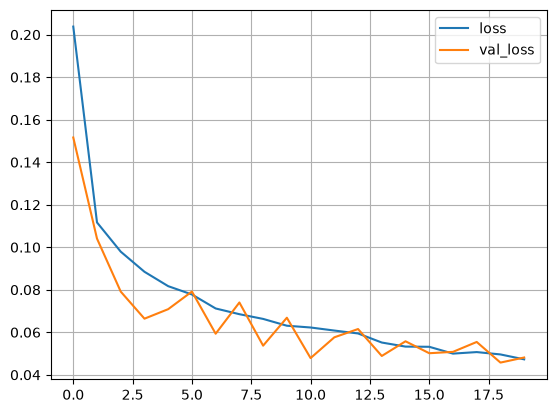

Minimum Validation Loss: 0.0457


In [32]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
plt.grid(True)
plt.show()
print(f"Minimum Validation Loss: {history_df['val_loss'].min():.4f}")

For testing the test accuracy, we have to concatenate the test dataset and then perform evaluation.

In [33]:
X_test_classifier = np.concatenate(
    [
        X_test_embeddings,
        X_test_scaled
    ],
    axis=1
)

test_loss, test_accuracy = classifier.evaluate(
    X_test_classifier,
    y_test
)

print(test_accuracy)

186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9810 - loss: 0.0518 
0.9809892177581787


We then produce the classification report and find the ROC-AUC curve of the model.

186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step    
              precision    recall  f1-score   support

      normal       0.97      0.99      0.98      3106
    phishing       0.99      0.97      0.98      2838

    accuracy                           0.98      5944
   macro avg       0.98      0.98      0.98      5944
weighted avg       0.98      0.98      0.98      5944

ROC-AUC: 0.9984


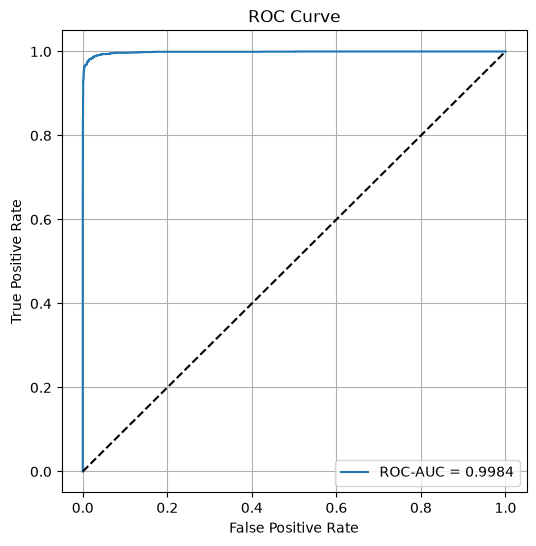

In [34]:
probs = classifier.predict(X_test_classifier).ravel()
y_pred = (probs > 0.5).astype(int)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "normal",
            "phishing"
        ]
    )
)

roc_auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

We also print the confusion matrix.

[[3084   22]
 [  91 2747]]


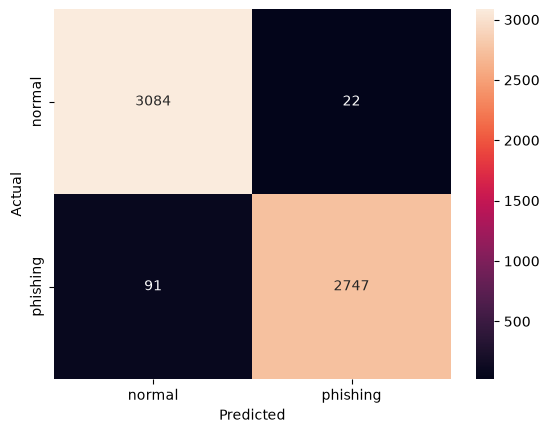

In [35]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["normal", "phishing"],
    yticklabels=["normal", "phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From analysis, we observe that our base model achieved:
- **Accuracy** (training / testing / validation): 0.9828 / 0.9810 / 0.9837
- **Minimum Loss** (training / validation): 0.0473 / 0.0457
- **classification report** (normal / phishing)
  - precision: 0.97 / 0.99
  - recall: 0.99 / 0.97
  - f1-score: 0.98 / 0.98
- **ROC-AUC**: ~0.99
- **False Negatives / False Positives**: 91 / 22

Since phishing detection should prioritize focusing on finding as many phishing emails as possible,
hence false negatives (where phishing emails are prioritized as normal) will be evaluated.

We first create a dataframe containing all the emails that the model failed to predict (`errors_df`), and then plot
the false negatives (FN) with `errors_df`

In [36]:
errors_df = pd.DataFrame({
    "text": X_test_text,
    "actual": y_test,
    "predicted": y_pred,
    "phishing_probability": probs.astype(np.float32)
})

errors_df = errors_df[errors_df.actual != errors_df.predicted]
false_negatives = errors_df[
    (errors_df.actual == 1) &
    (errors_df.predicted == 0)
    ]

false_negatives.sort_values("phishing_probability")

,text,actual,predicted,phishing_probability
58399,Investment Idea [SEP] This is a Brand New Comp...,1.0,0,0.000191
55001,Proposal for cooperation [SEP] Hello. I meant ...,1.0,0,0.000422
55153,Save 5.00 on Creamfields tickets [SEP] Creamfi...,1.0,0,0.005428
41928,No Subject [SEP] How come it takes so little t...,1.0,0,0.005959
56367,Re: Your E-Loan Refinance Application Declined...,1.0,0,0.008347
...,...,...,...,...
55010,Welcome to www.internationafreecall.com [SEP] ...,1.0,0,0.433105
5390,Very discrete shipping and billing [SEP] \nNow...,1.0,0,0.441406
54537,FREE HGH - Look 10 Years Younger in 3 Weeks!!!...,1.0,0,0.446045
54984,Internet Connectivity that beats the prices & ...,1.0,0,0.466309


We then split the false negatives based on the phishing probability that was assigned to each phishing email.

Based on values, we find that 32 of the 91 missed phishing emails lie within the probabilities between 0.25 to 0.5, suggesting that the majority of
false negatives (FNs) are caused by the model incorrectly detecting the emails as normal.

This suggests that half of the false negatives can be recovered by optimizing the decision threshold.

In [37]:
pd.cut(
    false_negatives.phishing_probability,
    bins=[0, 0.125, 0.25, 0.375, 0.5]
).value_counts()

phishing_probability
(0.0, 0.125]     37
(0.125, 0.25]    22
(0.25, 0.375]    19
(0.375, 0.5]     13
Name: count, dtype: int64

To find the optimal decision threshold, we use the validation dataset for evaluating and plotting a line charts showing the f1-score, percision and recall.

186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


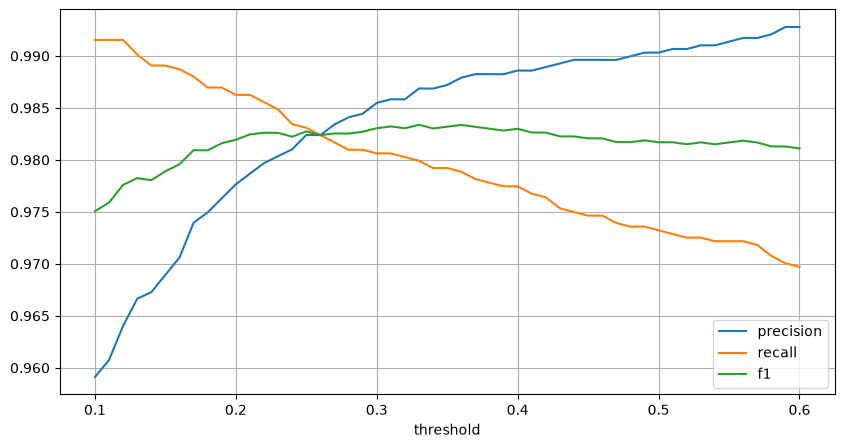

In [38]:
X_validate_classifier = np.concatenate(
    [X_validate_embeddings, X_validate_scaled],
    axis=1
)

validation_probs = classifier.predict(
    X_validate_classifier
).ravel()

threshold_results = []

for threshold in np.arange(0.10, 0.61, 0.01):
    pred = (validation_probs >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validate, pred),
        "recall": recall_score(y_validate, pred),
        "f1": f1_score(y_validate, pred)
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    figsize=(10, 5)
)

plt.grid()
plt.show()

We then find the optimal thresholds for maximizing values such as f1 and recall.

Since our goal is to minimize the amount of missed phishing emails classified as normal (FNs), we focus ond optimizing the threshold for recall by defining a target
recall value (99%) and obtaining the value with the highest precision.

In [39]:
# optimal f1
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_threshold)

threshold    0.330000
precision    0.986875
recall       0.979923
f1           0.983386
Name: 23, dtype: float64


In [40]:
# optimized for optimal recall target
required_recall = 0.99

recall_thres = threshold_results[
    threshold_results["recall"] >= required_recall
    ]

best_threshold = recall_thres.loc[
    recall_thres["precision"].idxmax()
]

print(best_threshold)

threshold    0.130000
precision    0.966644
recall       0.990137
f1           0.978250
Name: 3, dtype: float64


Based on our recall threshold, we find that the optimal threshold is 0.13 if we want to obtain a 0.99 recall for this model.

This process can be re-used for finding the optimal threshold for our optimized model below.

We define the same funnel architecture, but this time adding a 512d layer above, given that performance was good in the baseline model.

For compilation, we reduce the learning rate (LR) on Adam to smooth the validation curve.

In [41]:
classifier = keras.Sequential([
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

For training, we use an early stopping callback to ensure that the model converges successfully without significant overfitting of the training dataset.

We define a higher `epoch_size` of 50 to ensure convergence, since early stopping will stop the training early if the model is found to be overfitting.

In [42]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

history = classifier.fit(
    X_train_classifier,
    y_train,
    validation_data=(
        np.concatenate(
            [X_validate_embeddings, X_validate_scaled],
            axis=1
        ),
        y_validate
    ),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
)

Epoch 1/50


2026-08-11 12:27:09.793159: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-08-11 12:27:09.793203: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1486/1486 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8425 - loss: 0.4322 - val_accuracy: 0.9078 - val_loss: 0.2811
Epoch 2/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9237 - loss: 0.2215 - val_accuracy: 0.9401 - val_loss: 0.1797
Epoch 3/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9443 - loss: 0.1577 - val_accuracy: 0.9531 - val_loss: 0.1417
Epoch 4/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9539 - loss: 0.1301 - val_accuracy: 0.9578 - val_loss: 0.1240
Epoch 5/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9593 - loss: 0.1135 - val_accuracy: 0.9625 - val_loss: 0.1073
Epoch 6/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9640 - loss: 0.1018 - val_accuracy: 0.9645 - val_loss: 0.1005
Epoch 7/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9658 - loss: 0.0946 - val_accuracy: 0.9667 - val_loss: 0.0957
Epoch 8/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9689 - loss: 0.0873 - val_accura

After training, we plot the validation loss curve.

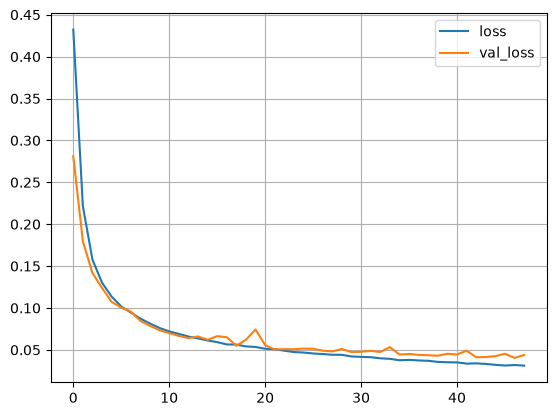

Minimum Validation Loss: 0.0404


In [43]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
plt.grid(True)
plt.show()
print(f"Minimum Validation Loss: {history_df['val_loss'].min():.4f}")

We then find the optimal threshold using the process used in the original model. We find that the optimal threshold for this model is 0.24.

In [44]:
validation_classifier = np.concatenate(
    [
        X_validate_embeddings,
        X_validate_scaled
    ],
    axis=1
)

validation_probs = classifier.predict(
    validation_classifier
).ravel()

threshold_results = []

for threshold in np.arange(0.1, 0.61, 0.01):
    pred = (validation_probs >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validate, pred),
        "recall": recall_score(y_validate, pred),
        "f1": f1_score(y_validate, pred)
    })

threshold_results = pd.DataFrame(threshold_results)
recall_thres = threshold_results[
    threshold_results["recall"] >= 0.99
]

best_threshold = recall_thres.loc[
    recall_thres["precision"].idxmax()
]

best_threshold_val = recall_thres.loc[
    recall_thres["precision"].idxmax(),
    "threshold"
]

print(best_threshold)

186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    
threshold    0.240000
precision    0.975703
recall       0.990137
f1           0.982867
Name: 14, dtype: float64


We perform evaluation of the test dataset.

In [45]:
X_test_classifier = np.concatenate(
    [
        X_test_embeddings,
        X_test_scaled
    ],
    axis=1
)

test_loss, test_accuracy = classifier.evaluate(
    X_test_classifier,
    y_test
)

print(test_accuracy)

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9857 - loss: 0.0473 
0.9856998920440674


After evaluating the test dataset, we apply the optimized threshold.

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step
              precision    recall  f1-score   support

      normal       0.99      0.98      0.98      3106
    phishing       0.98      0.99      0.98      2838

    accuracy                           0.98      5944
   macro avg       0.98      0.98      0.98      5944
weighted avg       0.98      0.98      0.98      5944

ROC-AUC: 0.9982


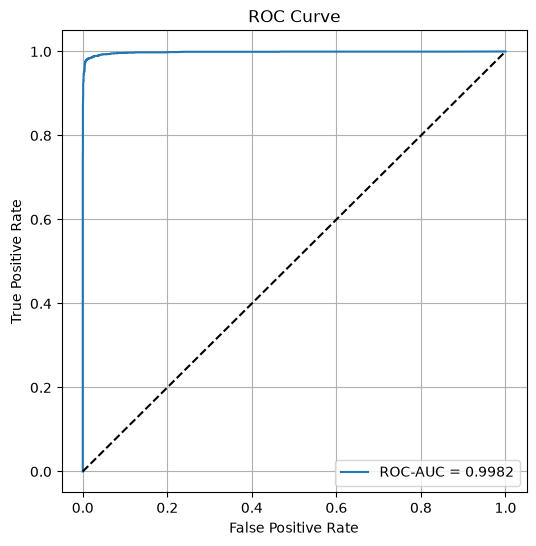

In [46]:
probs = classifier.predict(X_test_classifier).ravel()
y_pred = (probs > best_threshold_val).astype(int)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "normal",
            "phishing"
        ]
    )
)

roc_auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

[[3038   68]
 [  40 2798]]


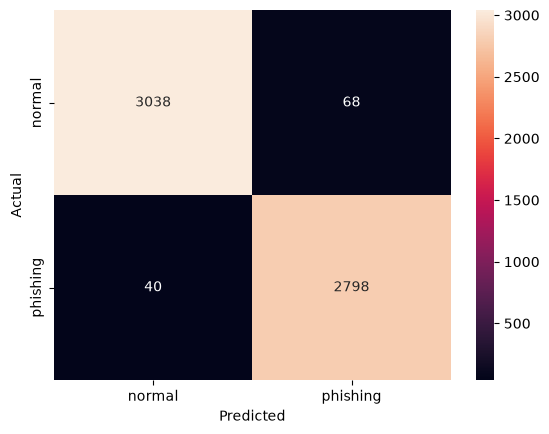

In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["normal", "phishing"],
    yticklabels=["normal", "phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From optimization, we were able to reliably reduce the number of false negatives (FNs) from 93 to 40,
while minimally affecting our test accuracy and ROC-AUC in the process.

From this analysis, we demostrate how combining pretrained BERT embeddings and feature engineered metadata can be an effective in detecting phishing emails.
Using the structural information of the emails and engineering features out of them, we were able to obtain useful features that are strong predictors in finding
phishing emails.

The baseline model achieves strong performance, with a test accuracy of 98.10% and a ROC-AUC of 0.9984.
However, evaluating the model using a default probability threshold of 0.5 resulted in 91 false negatives (FNs),
meaning that a notable number of phishing emails were incorrectly classified as legitimate.
Since failing to identify a phishing email can be more consequential than incorrectly flagging a legitimate email,
the decision threshold was subsequently optimized using the validation set.

The optimized model improved upon the baseline by increasing test accuracy to approximately 98.57%,
while maintaining a very high ROC-AUC of 0.9982.
More significantly, by utilizing a decision threshold of 0.24, we were able to increase phishing recall to approximately 99%
and reduce the number of false negatives from 91 to 40.
This represents a substantial improvement in the model's ability to identify phishing emails, while keeping the overall F1-score at approximately 0.98.

Hence, this analysis shows how combining contextual language representations with structured email metadata can produce a highly effective phishing classifier,